In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
df = pd.read_csv("vgsales.csv")

In [4]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# Практическая работа №4

## Первичный анализ данных

В работе используется датасет Video Game Sales.
Цель анализа — изучить структуру данных, типы признаков, пропущенные значения, основные статистические характеристики и визуально исследовать данные.

## 1. Размер таблицы

In [5]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

Количество строк: 16598
Количество столбцов: 11


## 2. Типы данных

In [6]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


## 3. Пропущенные значения

In [7]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Year,271
Publisher,58


In [9]:
missing_percent = df.isnull().mean() * 100

missing_percent[missing_percent > 0]

,0
Year,1.632727
Publisher,0.349440


## 4. Базовая статистика

In [10]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 5. Распределение глобальных продаж игр

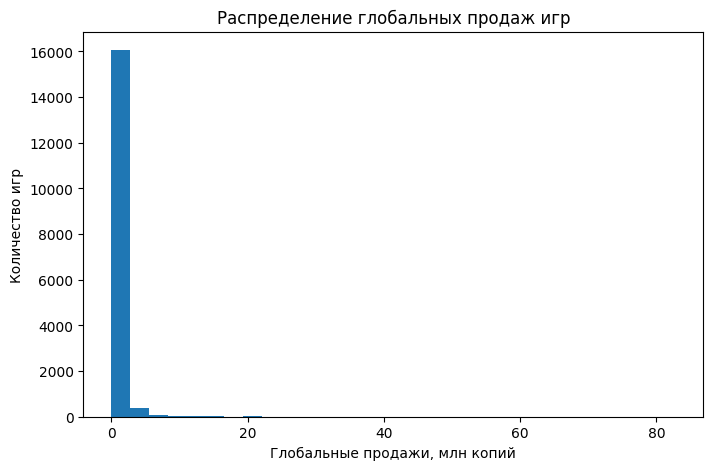

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["Global_Sales"], bins=30)

plt.title("Распределение глобальных продаж игр")
plt.xlabel("Глобальные продажи, млн копий")
plt.ylabel("Количество игр")

plt.show()

## 6. Соотношение жанров видеоигр

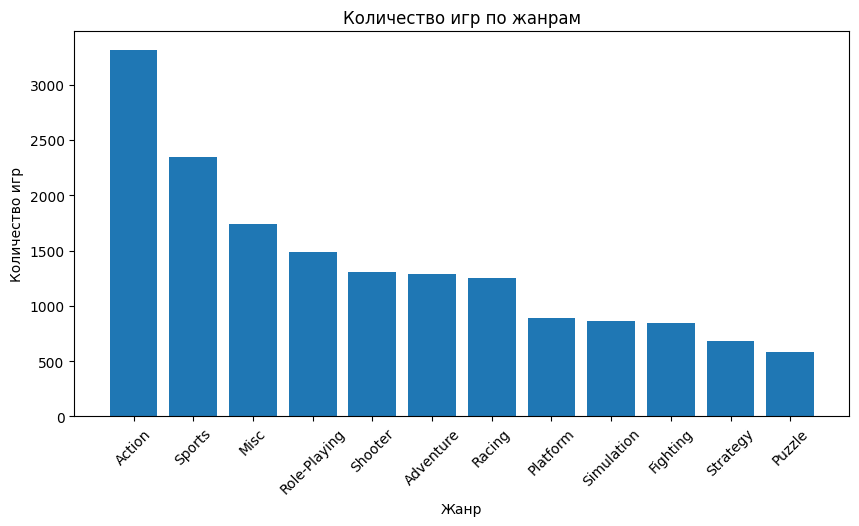

In [12]:
genre_counts = df["Genre"].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(genre_counts.index, genre_counts.values)

plt.title("Количество игр по жанрам")
plt.xlabel("Жанр")
plt.ylabel("Количество игр")

plt.xticks(rotation=45)

plt.show()

In [13]:
print("Количество жанров:", df["Genre"].nunique())
print("Количество платформ:", df["Platform"].nunique())
print("Количество издателей:", df["Publisher"].nunique())

Количество жанров: 12
Количество платформ: 31
Количество издателей: 578


## 7. Наблюдения

1. Пропуски в исходных данных встречаются не во всех столбцах: они сосредоточены главным образом в информации о годе выпуска и издателе. Это означает, что перед дальнейшим анализом этих признаков потребуется учитывать неполноту данных.

2. Распределение глобальных продаж сильно неравномерное: большая часть игр имеет сравнительно небольшие продажи, тогда как небольшое количество игр имеет значительно более высокие показатели. Поэтому среднее значение продаж может сильно зависеть от отдельных успешных игр.

3. Жанры представлены в данных неодинаково: некоторые категории содержат значительно больше игр, чем другие. Поэтому количество игр в жанре нельзя напрямую использовать как показатель коммерческого успеха жанра.

## 8. Итог

В ходе первичного анализа была изучена структура датасета Video Game Sales, определены размер таблицы и типы данных, выявлены пропущенные значения и рассчитаны базовые статистики. Также были построены графики распределения глобальных продаж и количества игр по жанрам.